In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from PIL import Image, UnidentifiedImageError
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Task 3: Load trained model

In [ ]:
train_mean = 0.606
train_std = 0.1944


class SafeImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.transform = transform
        self.valid_indices = []
        for i in range(len(self.dataset)):
            path, _ = self.dataset.samples[i]
            try:
                with open(path, "rb") as f:
                    Image.open(f).verify()
                self.valid_indices.append(i)
            except (UnidentifiedImageError, OSError):
                print(f"Skipping corrupted image: {path}")

        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.targets = [self.dataset.targets[i] for i in self.valid_indices]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        return self.dataset[self.valid_indices[idx]]


val_test_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[train_mean, train_mean, train_mean],
            std=[train_std, train_std, train_std],
        ),
    ]
)

test_dataset = SafeImageFolder(
    root="data_project_gray/test", transform=val_test_transform
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model_latent = models.resnet50()

num_features = model_latent.fc.in_features
model_latent.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_features, 1))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_latent.load_state_dict(
    torch.load("resnet50_finetuned_best.pth", map_location=device)
)
model_latent = model_latent.to(device)

model_latent.eval()  # evaluation mode
model_latent.fc = nn.Identity()  # remove last layer

### Extract latent representations

In [ ]:
# get full model
model_full = models.resnet50()
model_full.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_features, 1))
model_full.load_state_dict(
    torch.load("resnet50_finetuned_best.pth", map_location=device)
)
model_full = model_full.to(device)
model_full.eval()

latent_features_list = []
true_labels_list = []
pred_labels_list = []
confidences_list = []

In [ ]:
with torch.no_grad():
    for X, y in test_loader:
        X_device = X.to(device)

        # "Extract the latent feature vector from the last hidden layer"
        features = model_latent(X_device)

        # Prediction with full model
        logits = model_full(X_device)
        probs = torch.sigmoid(logits)

        preds = (probs >= 0.5).int()
        # "Store for each sample..."
        latent_features_list.append(features.cpu().numpy())
        true_labels_list.append(y.numpy())
        pred_labels_list.append(preds.cpu().numpy())
        confidences_list.append(probs.cpu().numpy())


latent_features = np.concatenate(latent_features_list, axis=0)
true_labels = np.concatenate(true_labels_list, axis=0)
pred_labels = np.concatenate(pred_labels_list, axis=0)
confidences = np.concatenate(confidences_list, axis=0)


[[3.14164117e-06]
 [8.89771763e-05]
 [3.39704275e-04]
 [8.92788637e-04]
 [6.48471614e-05]
 [1.36861280e-01]
 [8.90301380e-05]
 [6.00110681e-04]
 [5.07437158e-03]
 [8.70958672e-07]
 [8.21966387e-05]
 [2.38045948e-04]
 [2.06913282e-05]
 [1.20454864e-03]
 [3.81378457e-04]
 [6.13449674e-06]
 [2.82356108e-04]
 [3.93984956e-04]
 [7.74221771e-05]
 [2.61877285e-04]
 [7.45794823e-05]
 [5.34511446e-06]
 [1.69696112e-03]
 [7.85278082e-01]
 [3.41288745e-03]
 [6.96286043e-06]
 [4.83565709e-05]
 [1.94349695e-07]
 [2.30129153e-05]
 [1.22807339e-01]
 [7.83926516e-05]
 [2.16501090e-03]
 [3.72750359e-03]
 [1.19462718e-04]
 [3.65815172e-03]
 [2.16311280e-04]
 [3.49083621e-06]
 [6.88922778e-02]
 [1.97384230e-04]
 [2.22112903e-05]
 [1.22785874e-04]
 [2.12116996e-04]
 [4.13551837e-01]
 [3.03743221e-02]
 [1.25529128e-04]
 [1.94550648e-06]
 [4.57114329e-05]
 [1.09754615e-02]
 [4.35590535e-01]
 [4.62942808e-07]
 [5.94271999e-03]
 [1.36218114e-06]
 [1.29144965e-02]
 [1.64979708e-03]
 [1.33438527e-06]
 [6.710931

##### Dimensionality reduction

In [17]:
# PCA
pca = PCA(n_components=2, random_state=42)
latent_pca = pca.fit_transform(latent_features)

In [18]:
#t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(latent_features)

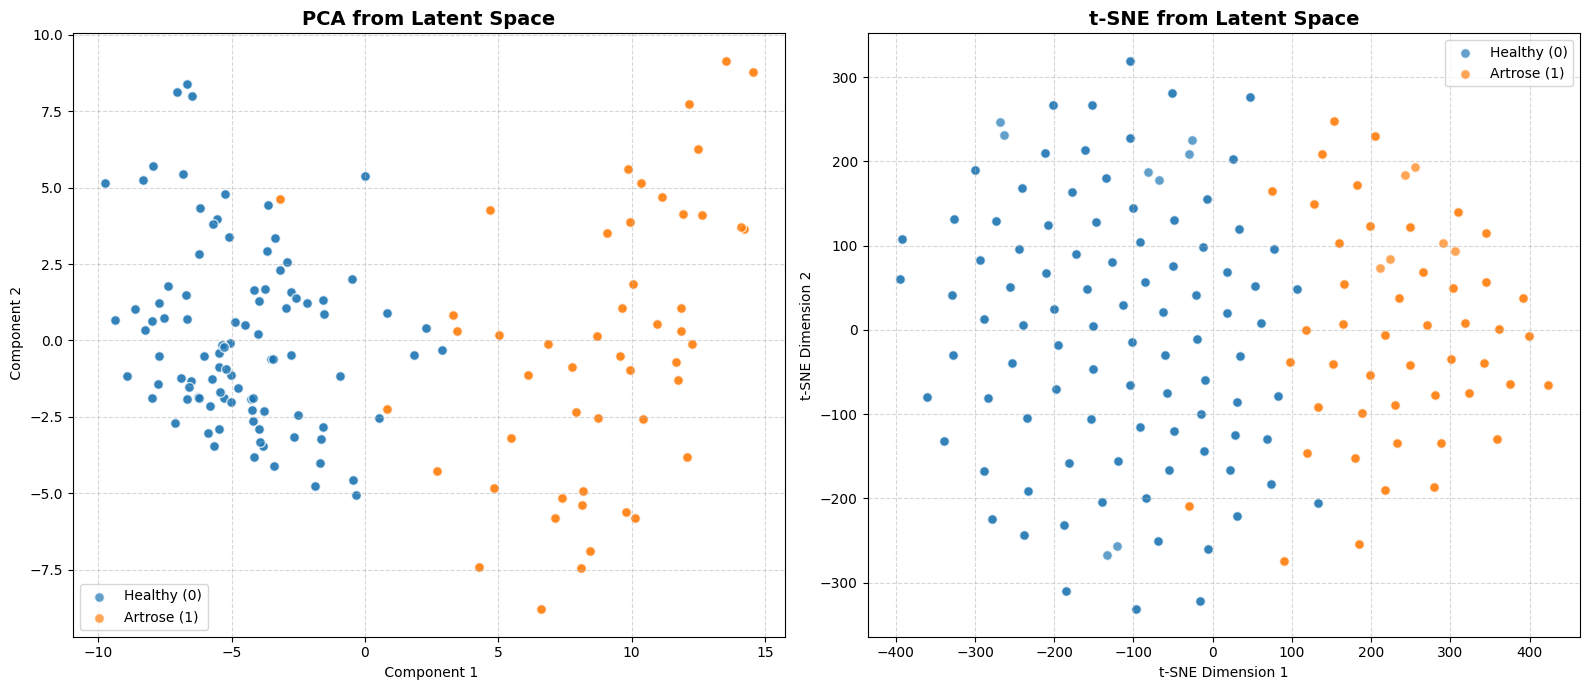

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#1f77b4', '#ff7f0e'] # Blue = healthy, orange= artrose
target_names = ['Healthy (0)', 'Artrose (1)']

#PCA
for i, color, target_name in zip([0, 1], colors, target_names):
    axes[0].scatter(latent_pca[true_labels == i, 0],
                    latent_pca[true_labels == i, 1],
                    color=color, alpha=0.7, label=target_name, edgecolors='w', s=50)
axes[0].set_title("PCA from Latent Space", fontsize=14, fontweight='bold')
axes[0].set_xlabel(" Component 1")
axes[0].set_ylabel(" Component 2")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

#t-SNE
for i, color, target_name in zip([0, 1], colors, target_names):
    axes[1].scatter(latent_tsne[true_labels == i, 0],
                    latent_tsne[true_labels == i, 1],
                    color=color, alpha=0.7, label=target_name, edgecolors='w', s=50)
axes[1].set_title("t-SNE from Latent Space", fontsize=14, fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

#### Comparison of PCA and t-SNE

PCA:
The PCA scatter plot demonstrates a very effective separation, mostly along the component 1 (horizontal) axis. The majority of the Healthy samples are located on the left side of the graph and the Osteoarthritis samples on the right side. 

t-SNE

#### Inspection of misclassified samples

In [29]:
true_flat = true_labels.flatten()
pred_flat = pred_labels.flatten()
error_indices = np.where(true_flat != pred_flat)[0]
correct_indices = np.where(true_flat == pred_flat)[0]

num_to_show = min(3, len(error_indices))

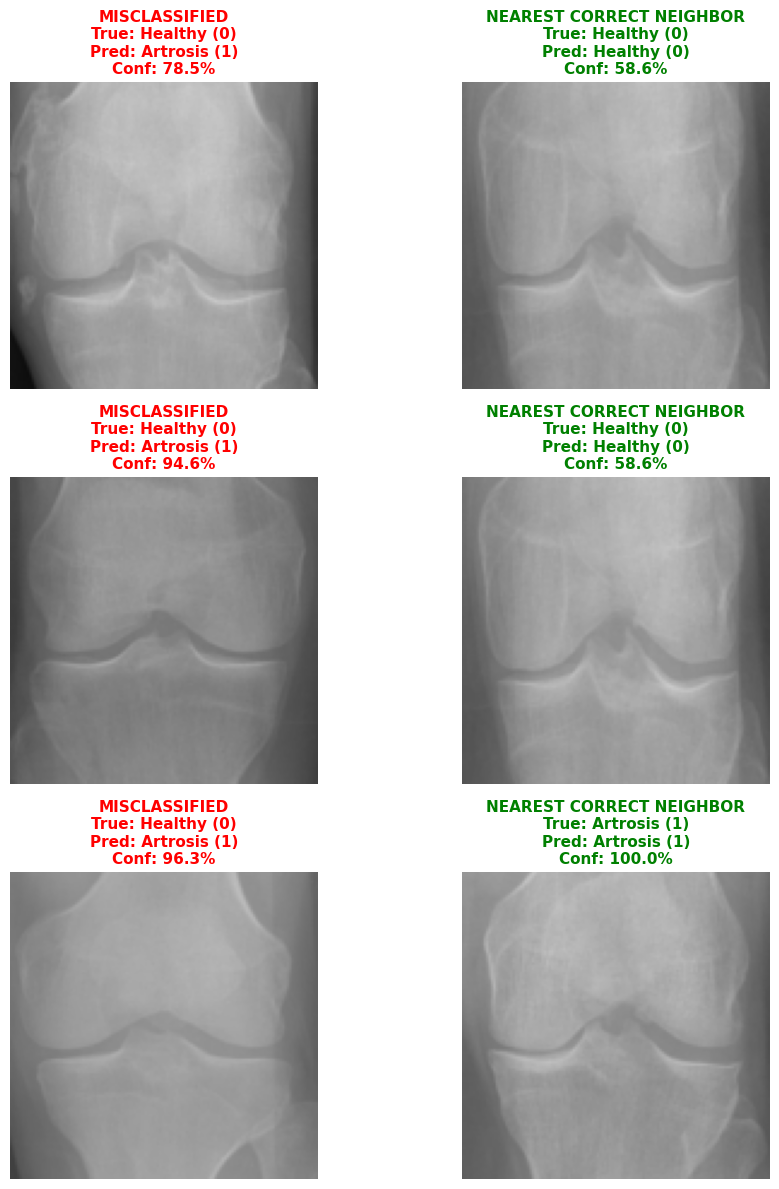

In [31]:
fig, axes = plt.subplots(num_to_show, 2, figsize=(10, 4 * num_to_show))
if num_to_show == 1:
    axes = [axes]

target_names = ['Healthy (0)', 'Artrosis (1)']

def imshow_denorm(tensor, ax, title, is_error):
    mean = torch.tensor([0.606, 0.606, 0.606]).view(3, 1, 1)
    std = torch.tensor([0.1944, 0.1944, 0.1944]).view(3, 1, 1)
    img = tensor * std + mean
    img = img.clamp(0, 1).numpy().transpose(1, 2, 0)
    ax.imshow(img)

    color = 'red' if is_error else 'green'
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.axis('off')

for i in range(num_to_show):
    err_idx = error_indices[i]
    err_true = int(true_labels[err_idx])
    err_pred = int(pred_labels[err_idx].item())
    err_conf = float(confidences[err_idx].item())
    if err_pred == 0:
        err_conf = 1.0 - err_conf

    distances = np.linalg.norm(latent_features[correct_indices] - latent_features[err_idx], axis=1)
    closest_correct_idx = correct_indices[np.argmin(distances)]

    corr_true = int(true_labels[closest_correct_idx])
    corr_pred = int(pred_labels[closest_correct_idx].item())
    corr_conf = float(confidences[closest_correct_idx].item())
    if corr_pred == 0:
        corr_conf = 1.0 - corr_conf

    img_err, _ = test_dataset[err_idx]
    title_err = f"MISCLASSIFIED\nTrue: {target_names[err_true]}\nPred: {target_names[err_pred]}\nConf: {err_conf:.1%}"
    imshow_denorm(img_err, axes[i][0], title_err, is_error=True)

    img_corr, _ = test_dataset[closest_correct_idx]
    title_corr = f"NEAREST CORRECT NEIGHBOR\nTrue: {target_names[corr_true]}\nPred: {target_names[corr_pred]}\nConf: {corr_conf:.1%}"
    imshow_denorm(img_corr, axes[i][1], title_corr, is_error=False)


plt.tight_layout()
plt.show()